# Aim:
Given a graph, the produced AI should find an independent set of largest size.

Independent set: 

Let $G = (V,E)$ be a graph. An independent set $X \subseteq V$ is a set of vertices from the graph $G$ such that no two distinct vertices $v,w \in X$ share an edge, i.e. $vw \notin E$ $\forall v,w \in V, v \neq w$.

In [34]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import random
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import time
import pygame
import core as Graphs
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from collections import deque
import torch.optim as optim

c:\Users\sp4re\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate a random graph for the AI to operate on

In [2]:
graph = Graphs.Graph()      # G = (n,p)
num_vertices = 10       # Set number of vertices (n)
edge_probability = 0.5  # Set probability of edge existing between two vertices (p)

for i in range(num_vertices): 
    graph.add_node(Graphs.Vertex(str(i)))

graph_vertices = graph.get_nodes()


for v in range(len(graph_vertices)-1):
    for w in range(v, len(graph_vertices)):
        if random.uniform(0,1) >= 0.8:
            graph.add_edge(Graphs.Edge(graph_vertices[v],graph_vertices[w],False))

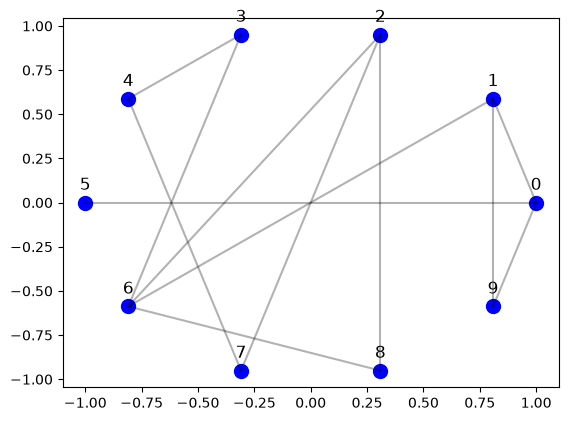

In [3]:
graph.visualise()

In [14]:
class GraphEnv:
    def __init__(self,n,p):
        self.n = n
        self.p = p
        self.graph = None
        self.fixed_graph = None
        self.node_states = {}
        self.reset()

    def reset(self, use_fixed = False):
        if use_fixed and self.fixed_graph is not None:
            self.graph = self.fixed_graph
        else:
            graph = Graphs.Graph()      # G = (n,p)
            num_vertices = self.n       # Set number of vertices (n)
            edge_probability = self.p  # Set probability of edge existing between two vertices (p)

            for i in range(num_vertices): 
                graph.add_node(Graphs.Vertex(str(i)))

            graph_vertices = graph.get_nodes()


            for v in range(len(graph_vertices)-1):
                for w in range(v+1, len(graph_vertices)):
                    if random.uniform(0,1) <= edge_probability:
                        graph.add_edge(Graphs.Edge(graph_vertices[v],graph_vertices[w],False))            

            self.graph = graph

        self.node_states = {node:0 for node in self.graph.get_nodes()}
        return self.get_state_representation()
    
    def get_state_representation(self):
        nodes = self.graph.get_nodes()
        n = len(nodes)

        node_to_idx = {node:idx for idx, node in enumerate(nodes)}

        X = np.zeros((n,1),dtype=np.float32)
        for node,state in self.node_states.items():
            idx = node_to_idx[node]
            X[idx,0] = state
        
        sources = []
        targets = []

        for edge in self.graph.get_edges():
            u_idx = node_to_idx[edge.v1]
            v_idx = node_to_idx[edge.v2]

            sources.append(u_idx)
            targets.append(v_idx)

            sources.append(v_idx)
            targets.append(u_idx)

        edge_index = np.array([sources,targets], dtype=np.int64)

        return X, edge_index, node_to_idx

    def step(self, action_node : Graphs.Vertex):
        if self.node_states[action_node] != 0:
            return self.get_state_representation(), -5, True
        
        self.node_states[action_node] = 1
        neighbours = self.graph.get_neighbors(action_node)
        for neighbour in neighbours:
            if self.node_states[neighbour] == 0:
                self.node_states[neighbour] = -1

        
        reward = 1.0 
        done = all(state != 0 for state in self.node_states.values())

        return self.get_state_representation(), reward, done
    


    

 --- Starting Random Simulator Test --- 
Initial State Matrix Shape: (50, 1)
Edge Index Matrix:
[[ 0  3  0 ... 49 47 48]
 [ 3  0  4 ... 46 48 47]]
Node to Index Map: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, '21': 21, '22': 22, '23': 23, '24': 24, '25': 25, '26': 26, '27': 27, '28': 28, '29': 29, '30': 30, '31': 31, '32': 32, '33': 33, '34': 34, '35': 35, '36': 36, '37': 37, '38': 38, '39': 39, '40': 40, '41': 41, '42': 42, '43': 43, '44': 44, '45': 45, '46': 46, '47': 47, '48': 48, '49': 49}



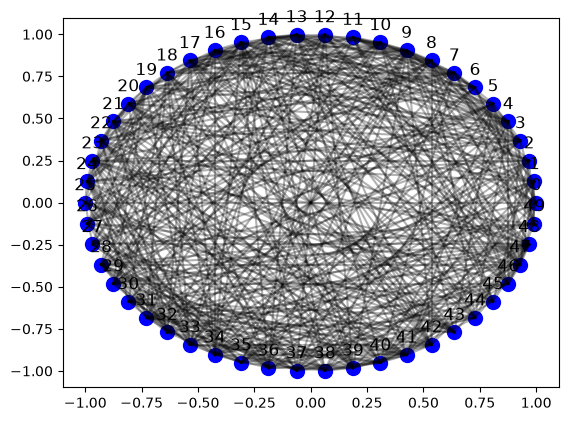

Step 1
Agent chose node 40
Step Reward: 1.0 | Total Reward: 1.0
Done: False
Step 2
Agent chose node 29
Step Reward: 1.0 | Total Reward: 2.0
Done: False
Step 3
Agent chose node 23
Step Reward: 1.0 | Total Reward: 3.0
Done: False
Step 4
Agent chose node 20
Step Reward: 1.0 | Total Reward: 4.0
Done: False
Step 5
Agent chose node 25
Step Reward: 1.0 | Total Reward: 5.0
Done: False
Step 6
Agent chose node 26
Step Reward: 1.0 | Total Reward: 6.0
Done: True
Simulation complete
Total vertices in independent set: 6.0


In [15]:
env = GraphEnv(n=50, p=0.4)
print(" --- Starting Random Simulator Test --- ")
X, edge_index, node_to_idx = env.reset()

print(f"Initial State Matrix Shape: {X.shape}")
print(f"Edge Index Matrix:\n{edge_index}")
print(f"Node to Index Map: { {node.label: idx for node, idx in node_to_idx.items()} }\n")

env.graph.visualise()

done = False
total_reward = 0.0
step_count = 0

while not done:
    step_count += 1
    print(f"Step {step_count}")

    eligible_nodes = [node for node, state in env.node_states.items() if state == 0]

    chosen_action_node = random.choice(eligible_nodes)
    print(f"Agent chose node {chosen_action_node.label}")

    (next_X, next_edge_index, _), reward, done = env.step(chosen_action_node)
    total_reward += reward

    # print("Updated Vertex States:")
    # for node, idx in node_to_idx.items():
    #     print(f" Node {node.label} (index {idx}) : State = {next_X[idx,0]}")

    print(f"Step Reward: {reward} | Total Reward: {total_reward}")
    print(f"Done: {done}")


print("Simulation complete")
print(f"Total vertices in independent set: {total_reward}")




In [16]:
class QNetwork(nn.Module):
    def __init__(self):
        super(QNetwork, self).__init__()
        # Layer 1: Takes 1 input feature (the state -1, 0, or 1) and outputs 32 hidden features
        self.conv1 = GCNConv(in_channels=1, out_channels=32)
        
        # Layer 2: Aggregates features further to look deeper into the graph neighborhoods
        self.conv2 = GCNConv(in_channels=32, out_channels=32)
        
        # Layer 3: Condenses the hidden features down to a single score (Q-value) per node
        self.conv3 = GCNConv(in_channels=32, out_channels=1)

    def forward(self, x, edge_index):
        # x shape: (n, 1), edge_index shape: (2, number_of_edges)
        
        # Pass through the first GCN layer and apply a ReLU activation function
        x = F.relu(self.conv1(x, edge_index))
        
        # Pass through the second GCN layer
        x = F.relu(self.conv2(x, edge_index))
        
        # Final layer outputs a single Q-value for each vertex
        q_values = self.conv3(x, edge_index)
        
        return q_values.squeeze(-1)  # Flattens output to shape (n,)

In [17]:
def prepare_tensors(X, edge_index):
    """Converts NumPy arrays from the environment into PyTorch tensors."""
    x_tensor = torch.tensor(X, dtype=torch.float32)
    edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)
    return x_tensor, edge_index_tensor

In [18]:
def select_action(q_values, node_states, node_to_idx, epsilon):
    """Selects an eligible node using an epsilon-greedy strategy."""
    
    # 1. Identify which nodes are currently valid (state == 0)
    eligible_nodes = [node for node, state in node_states.items() if state == 0]
    
    # Exploration: Choose a completely random valid node
    if random.uniform(0, 1) < epsilon:
        return random.choice(eligible_nodes)
    
    # Exploitation: Use the GNN's predictions
    else:
        # Create a copy of Q-values so we don't overwrite network data
        masked_q = q_values.clone().detach()
        
        # Set the Q-values of all INVALID actions to a massive negative number
        for node, state in node_states.items():
            if state != 0:
                idx = node_to_idx[node]
                masked_q[idx] = -1e9  # The AI will never pick this
        
        # Find the index of the highest remaining Q-value
        best_idx = torch.argmax(masked_q).item()
        
        # Map that numeric index back to your custom Vertex object
        idx_to_node = {idx: node for node, idx in node_to_idx.items()}
        return idx_to_node[best_idx]

In [19]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        # A deque will automatically evict the oldest memory when capacity is full
        self.buffer = deque(maxlen=capacity)
        
    def push(self, x, edge_index, action_idx, reward, next_x, next_edge_index, done):
        """Saves a single state transition tuple."""
        self.buffer.append((x, edge_index, action_idx, reward, next_x, next_edge_index, done))
        
    def sample(self, batch_size):
        """Samples a random batch of transitions."""
        return random.sample(self.buffer, batch_size)
        
    def __len__(self):
        return len(self.buffer)


In [ ]:
# Hyperparameters
GAMMA = 0.99          # Discount factor for future rewards
BATCH_SIZE = 32
LR = 0.001            # Learning rate for Adam optimizer

model = QNetwork()
optimizer = optim.Adam(model.parameters(), lr=LR)
memory = ReplayBuffer()

def train_step():
    if len(memory) < BATCH_SIZE:
        return  # Wait until we have enough experiences to sample a full batch
        
    batch = memory.sample(BATCH_SIZE)
    loss = 0
    
    # Process each transition in the batch
    for x, edge_index, action_idx, reward, next_x, next_edge_index, done in batch:
        
        # 1. Convert everything to PyTorch tensors
        x_t = torch.tensor(x, dtype=torch.float32)
        edge_index_t = torch.tensor(edge_index, dtype=torch.long)
        next_x_t = torch.tensor(next_x, dtype=torch.float32)
        next_edge_index_t = torch.tensor(next_edge_index, dtype=torch.long)
        
        # 2. Get current predicted Q-value for the action that was taken
        current_q_values = model(x_t, edge_index_t)
        predicted_q = current_q_values[action_idx]
        
        # 3. Calculate target Q-value using Bellman Equation
        if done:
            target_q = torch.tensor(reward, dtype=torch.float32)
        else:
            with torch.no_grad(): # No gradients needed for target calculation
                next_q_values = model(next_x_t, next_edge_index_t)
                # Mask out invalid actions in the next state if desired, 
                # or take the absolute maximum of valid actions
                max_next_q = torch.max(next_q_values)
                target_q = reward + GAMMA * max_next_q
                
        # 4. Accumulate Mean Squared Error (MSE) Loss
        loss += F.mse_loss(predicted_q, target_q)
        
    # 5. Optimize the weights of the GNN
    loss = loss / BATCH_SIZE # Average the loss over the batch
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [21]:
# Training parameters
NUM_EPISODES = 1000
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995

epsilon = EPSILON_START
env = GraphEnv(n=15, p=0.3) # Train on graphs of size 15

for episode in range(NUM_EPISODES):
    # 1. Reset environment to get a brand-new random graph
    X, edge_index, node_to_idx = env.reset(use_fixed=False)
    done = False
    episode_reward = 0
    
    while not done:
        # Prepare current tensors to feed into action selection
        x_tensor, edge_index_tensor = prepare_tensors(X, edge_index)
        
        # 2. Get Q-values from GNN
        with torch.no_grad():
            q_values = model(x_tensor, edge_index_tensor)
            
        # 3. Select action node object and find its corresponding numerical matrix index
        action_node = select_action(q_values, env.node_states, node_to_idx, epsilon)
        action_idx = node_to_idx[action_node]
        
        # 4. Step environment forward
        (next_X, next_edge_index, next_node_to_idx), reward, done = env.step(action_node)
        episode_reward += reward
        
        # 5. Save this experience to our memory buffer
        memory.push(X, edge_index, action_idx, reward, next_X, next_edge_index, done)
        
        # 6. Move to next state
        X, edge_index, node_to_idx = next_X, next_edge_index, next_node_to_idx
        
        # 7. Run a training update step
        train_step()
        
    # Decay exploration rate
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    
    # Print progress every 50 episodes
    if episode % 50 == 0:
        print(f"Episode {episode} | Avg Independent Set Size: {episode_reward:.1f} | Epsilon: {epsilon:.2f}")

Episode 0 | Avg Independent Set Size: 6.0 | Epsilon: 0.99
Episode 50 | Avg Independent Set Size: 6.0 | Epsilon: 0.77
Episode 100 | Avg Independent Set Size: 3.0 | Epsilon: 0.60
Episode 150 | Avg Independent Set Size: 3.0 | Epsilon: 0.47
Episode 200 | Avg Independent Set Size: 4.0 | Epsilon: 0.37
Episode 250 | Avg Independent Set Size: 4.0 | Epsilon: 0.28
Episode 300 | Avg Independent Set Size: 3.0 | Epsilon: 0.22
Episode 350 | Avg Independent Set Size: 5.0 | Epsilon: 0.17
Episode 400 | Avg Independent Set Size: 5.0 | Epsilon: 0.13
Episode 450 | Avg Independent Set Size: 5.0 | Epsilon: 0.10
Episode 500 | Avg Independent Set Size: 4.0 | Epsilon: 0.08
Episode 550 | Avg Independent Set Size: 4.0 | Epsilon: 0.06
Episode 600 | Avg Independent Set Size: 4.0 | Epsilon: 0.05
Episode 650 | Avg Independent Set Size: 5.0 | Epsilon: 0.05
Episode 700 | Avg Independent Set Size: 5.0 | Epsilon: 0.05
Episode 750 | Avg Independent Set Size: 3.0 | Epsilon: 0.05
Episode 800 | Avg Independent Set Size: 4.0

In [22]:
torch.save(model.state_dict(), "gnm_mis_model.pth")

# To load them back later into a fresh script
loaded_model = QNetwork()
loaded_model.load_state_dict(torch.load("gnm_mis_model.pth"))
loaded_model.eval() # Set to evaluation mode

C:\Users\sp4re\AppData\Local\Temp\ipykernel_14676\4031691155.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("gnm_mis_model.pth")

QNetwork(
  (conv1): GCNConv(1, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 1)
)

--- Evaluating Trained GNN on a New Graph ---
GNN picked Node 3 (Predicted Q-Value: 9.8942)
GNN picked Node 0 (Predicted Q-Value: 9.3423)
GNN picked Node 2 (Predicted Q-Value: 9.3423)
GNN picked Node 6 (Predicted Q-Value: 8.9787)
GNN successfully found an Independent Set!
Size of Independent Set: 4
Chosen Vertices: ['3', '0', '2', '6']


C:\Users\sp4re\AppData\Local\Temp\ipykernel_14676\3710220310.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("gnm_mis_model.pth"))


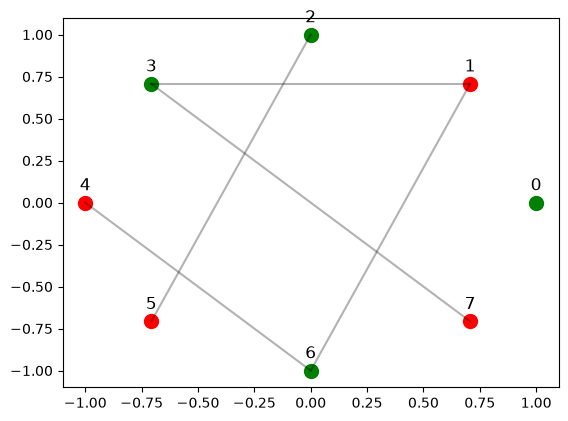

In [ ]:
# 1. Instantiate your network and load the trained weights
model = QNetwork()
model.load_state_dict(torch.load("gnm_mis_model.pth"))

# Put the model in evaluation mode. 
# This turns off things like dropout or batch normalization calculations.
model.eval()

# 2. Set up your environment with a completely new graph size
eval_env = GraphEnv(n=8, p=0.25)

print("--- Evaluating Trained GNN on a New Graph ---")
X, edge_index, node_to_idx = eval_env.reset(use_fixed=False)
done = False
independent_set = []

# 3. Let the GNN solve the graph step-by-step
while not done:
    # Convert numpy matrices from the environment into PyTorch tensors
    x_tensor = torch.tensor(X, dtype=torch.float32)
    edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)
    
    with torch.no_grad():
        q_values = model(x_tensor, edge_index_tensor)
    
    # --- ACTION MASKING ---
    # We must force the model to only choose eligible nodes (state == 0)
    masked_q = q_values.clone()
    for node, state in eval_env.node_states.items():
        if state != 0:
            idx = node_to_idx[node]
            masked_q[idx] = -1e9  # Mask out banned or already chosen nodes
            
    # Pick the node with the absolute highest Q-value score
    best_idx = torch.argmax(masked_q).item()
    
    # Map that numeric index back to your custom Vertex object
    idx_to_node = {idx: node for node, idx in node_to_idx.items()}
    chosen_node = idx_to_node[best_idx]
    
    # Track the chosen node for our final answer
    independent_set.append(chosen_node.label)
    print(f"GNN picked Node {chosen_node.label} (Predicted Q-Value: {masked_q[best_idx].item():.4f})")
    
    # Step the environment forward with our chosen node
    (next_X, next_edge_index, next_node_to_idx), reward, done = eval_env.step(chosen_node)
    
    # Update variables for the next turn
    X, edge_index, node_to_idx = next_X, next_edge_index, next_node_to_idx

print("==========================================")
print(f"GNN successfully found an Independent Set!")
print(f"Size of Independent Set: {len(independent_set)}")
print(f"Chosen Vertices: {independent_set}")
print("==========================================")

eval_env.graph.visualise(node_states=eval_env.node_states)